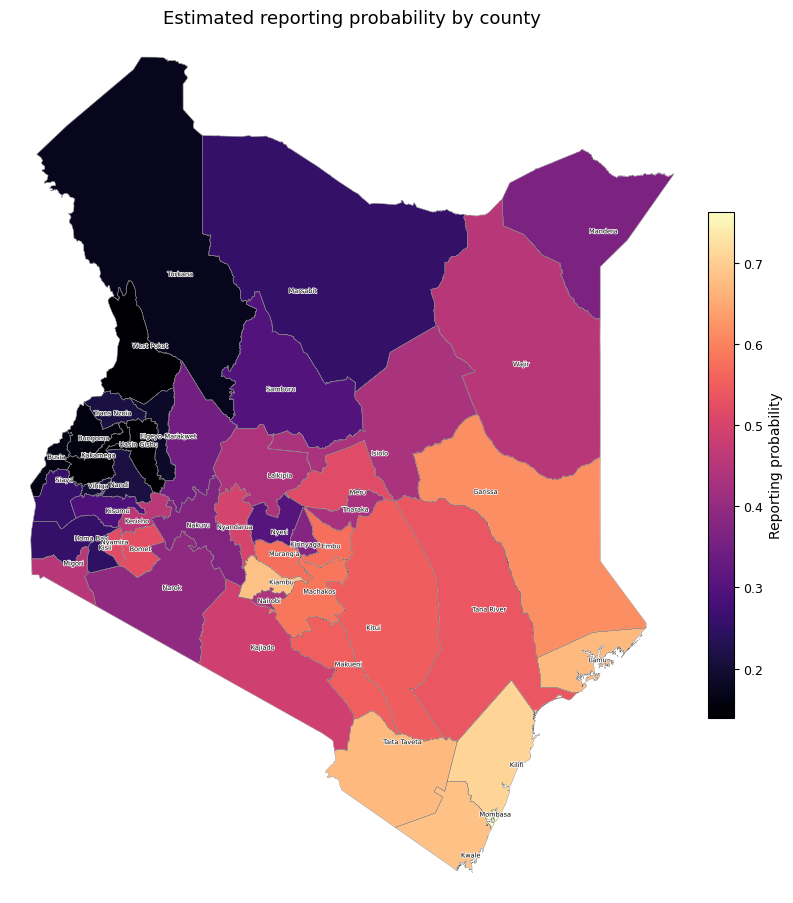

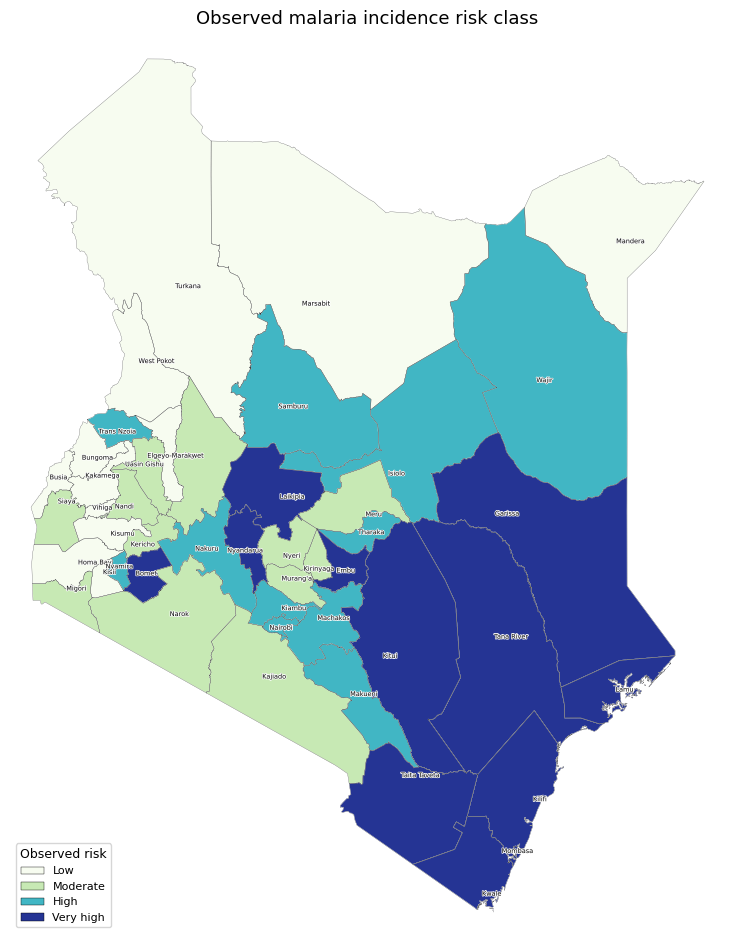

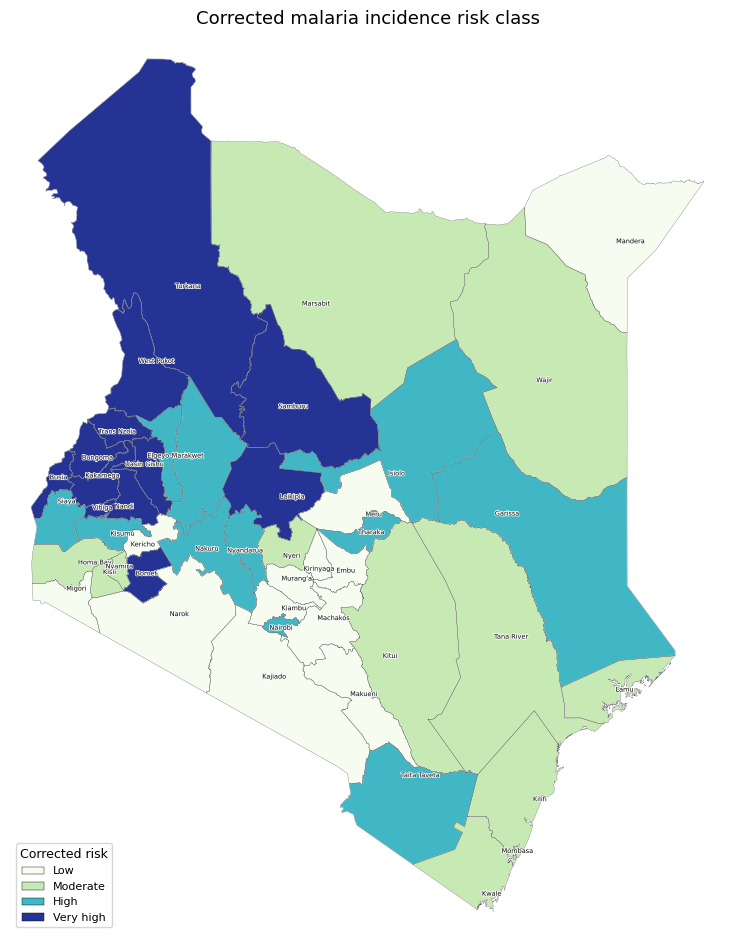

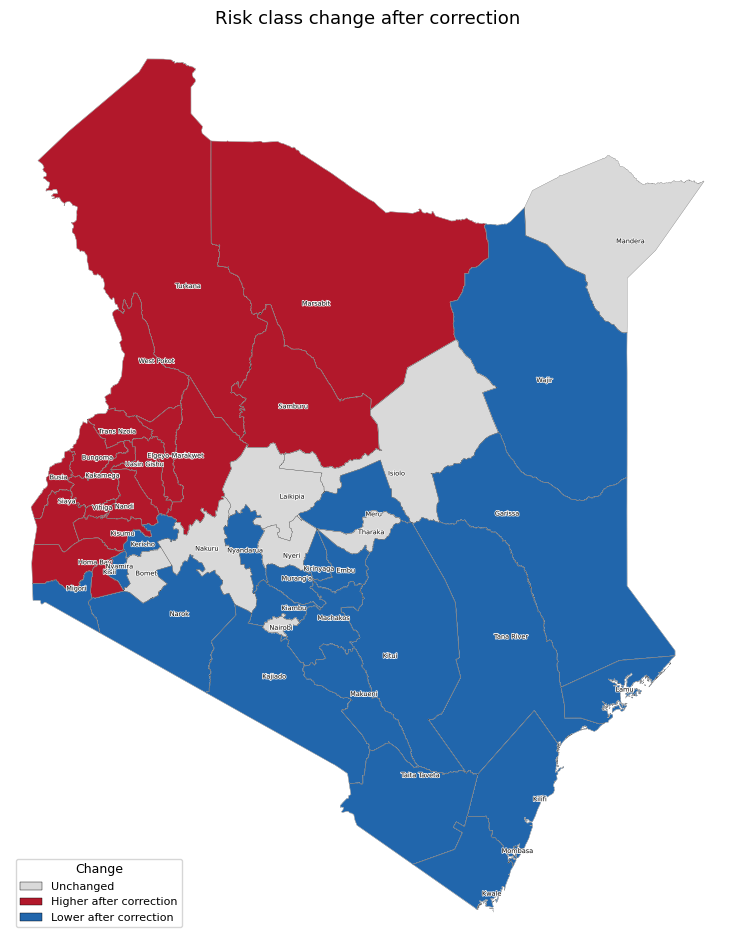

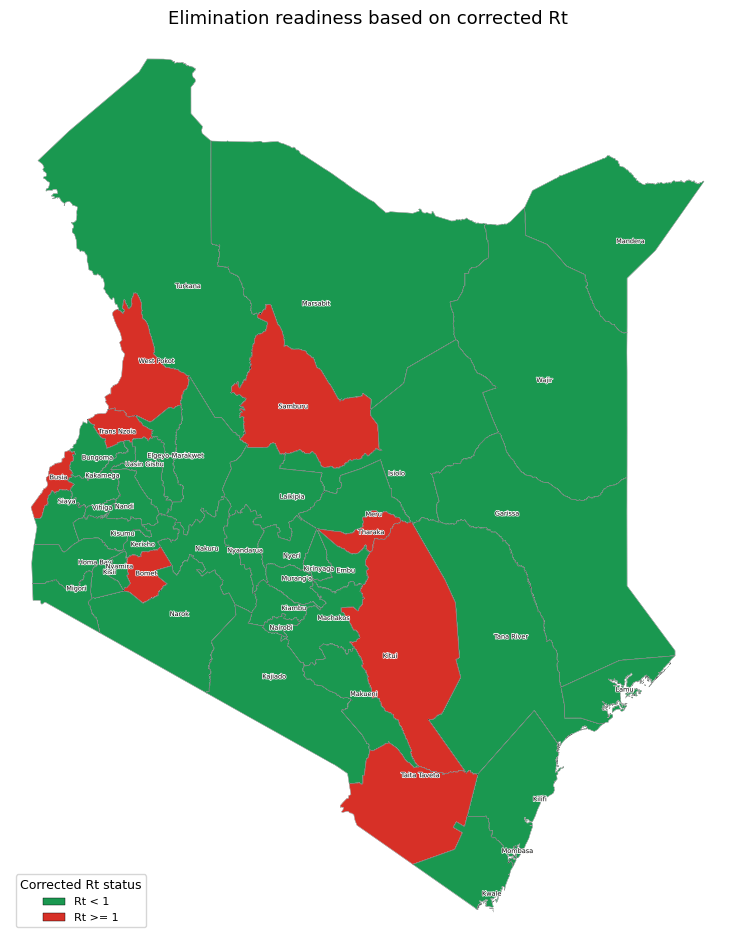

Finished generating county maps with no missing counties.
Files saved in
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps_no_missing

Number of Kenya counties in shapefile
47

Number of counties with mapped values
47

Minimum number of assigned synthetic units per county
1

Maximum number of assigned synthetic units per county
12
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps_no_missing\map1_reporting_probability_no_missing_with_county_names.png
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps_no_missing\map2_observed_risk_class_no_missing_with_county_names.png
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps_no_missing\map3_corrected_risk_class_no_missing_with_county_names.png
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps_no_missing\map4_risk_class_change_no_missing_with_county_names.png
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps_no_missing\map5_corrected_rt_status_no_missing_with_county_names.png

Risk

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as path_effects

from pathlib import Path
from matplotlib.path import Path as MplPath
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection


np.random.seed(42)


BASE_DIR = Path(r"C:\Users\Tosin\Desktop\Malaria\Kenya")

GEOJSON_PATH = BASE_DIR / "geoBoundaries-KEN-ADM1.geojson"
ANALYTIC_DATA_PATH = BASE_DIR / "synthetic_kenya_malaria_analytic_dataset.csv"

OUTPUT_DIR = BASE_DIR / "kenya_final_county_maps_no_missing"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)


df = pd.read_csv(ANALYTIC_DATA_PATH, parse_dates=["date"])

latest_date = df["date"].max()
latest = df[df["date"] == latest_date].copy()


def estimate_rt(incidence, generation_interval):
    incidence = np.asarray(incidence, dtype=float)
    w = np.asarray(generation_interval, dtype=float)
    w = w / w.sum()

    rt = np.full(len(incidence), np.nan)

    for t in range(1, len(incidence)):
        max_lag = min(t, len(w))
        past = incidence[t - np.arange(1, max_lag + 1)]
        infectiousness = np.sum(past * w[:max_lag])

        if infectiousness > 0:
            rt[t] = incidence[t] / infectiousness

    return rt


generation_interval = np.array([0.25, 0.35, 0.25, 0.10, 0.05])

rt_rows = []

for sid, g in df.groupby("subcounty_id"):
    g = g.sort_values("date").copy()
    g["Rt_observed"] = estimate_rt(g["observed_cases"].values, generation_interval)
    g["Rt_corrected"] = estimate_rt(g["corrected_cases"].values, generation_interval)
    rt_rows.append(g[["subcounty_id", "date", "Rt_observed", "Rt_corrected"]])

rt_df = pd.concat(rt_rows, ignore_index=True)

latest = latest.merge(
    rt_df[rt_df["date"] == latest_date][["subcounty_id", "Rt_observed", "Rt_corrected"]],
    on="subcounty_id",
    how="left"
)


with open(GEOJSON_PATH, "r", encoding="utf-8") as f:
    geo = json.load(f)


def get_county_name(properties):
    possible_keys = ["shapeName", "ADM1_EN", "NAME_1", "name", "County", "county"]

    for key in possible_keys:
        if key in properties and properties[key] is not None:
            return str(properties[key])

    return str(properties)


def polygon_rings_from_geometry(geometry):
    rings = []

    if geometry["type"] == "Polygon":
        if len(geometry["coordinates"]) > 0:
            rings.append(np.asarray(geometry["coordinates"][0], dtype=float))

    elif geometry["type"] == "MultiPolygon":
        for polygon in geometry["coordinates"]:
            if len(polygon) > 0:
                rings.append(np.asarray(polygon[0], dtype=float))

    return rings


counties = []

for feature in geo["features"]:
    rings = polygon_rings_from_geometry(feature["geometry"])

    if rings:
        counties.append(
            {
                "name": get_county_name(feature["properties"]),
                "rings": rings
            }
        )


all_coords = np.vstack([ring for county in counties for ring in county["rings"]])

lon_min, lat_min = all_coords.min(axis=0)
lon_max, lat_max = all_coords.max(axis=0)


for county in counties:
    county["paths"] = [MplPath(ring[:, :2]) for ring in county["rings"]]


county_centroids = []

for county in counties:
    largest_ring = max(county["rings"], key=lambda ring: len(ring))
    centroid = largest_ring.mean(axis=0)

    county_centroids.append(
        {
            "county_name": county["name"],
            "centroid_lon": centroid[0],
            "centroid_lat": centroid[1]
        }
    )

county_centroids = pd.DataFrame(county_centroids)


spatial = latest[["subcounty_id", "x", "y"]].drop_duplicates().copy()

spatial["lon_raw"] = (
    lon_min
    + (spatial["x"] - spatial["x"].min())
    / (spatial["x"].max() - spatial["x"].min())
    * (lon_max - lon_min)
)

spatial["lat_raw"] = (
    lat_min
    + (spatial["y"] - spatial["y"].min())
    / (spatial["y"].max() - spatial["y"].min())
    * (lat_max - lat_min)
)


distance_rows = []

for county_i, county_row in county_centroids.iterrows():
    for unit_i, unit_row in spatial.iterrows():
        d = (
            (county_row["centroid_lon"] - unit_row["lon_raw"]) ** 2
            + (county_row["centroid_lat"] - unit_row["lat_raw"]) ** 2
        )

        distance_rows.append(
            {
                "county_i": county_i,
                "unit_i": unit_i,
                "county_name": county_row["county_name"],
                "subcounty_id": unit_row["subcounty_id"],
                "distance": d
            }
        )

distance_df = pd.DataFrame(distance_rows)
distance_df = distance_df.sort_values("distance").reset_index(drop=True)

assigned_units = set()
assigned_counties = set()
initial_assignments = []

for _, row in distance_df.iterrows():
    if row["county_name"] not in assigned_counties and row["subcounty_id"] not in assigned_units:
        initial_assignments.append(
            {
                "subcounty_id": row["subcounty_id"],
                "county_name": row["county_name"]
            }
        )

        assigned_counties.add(row["county_name"])
        assigned_units.add(row["subcounty_id"])

    if len(assigned_counties) == len(county_centroids):
        break


initial_assignment_df = pd.DataFrame(initial_assignments)

remaining_units = spatial[~spatial["subcounty_id"].isin(assigned_units)].copy()

remaining_assignments = []

for _, unit_row in remaining_units.iterrows():
    distance = (
        (county_centroids["centroid_lon"] - unit_row["lon_raw"]) ** 2
        + (county_centroids["centroid_lat"] - unit_row["lat_raw"]) ** 2
    )

    county_name = county_centroids.loc[distance.idxmin(), "county_name"]

    remaining_assignments.append(
        {
            "subcounty_id": unit_row["subcounty_id"],
            "county_name": county_name
        }
    )

remaining_assignment_df = pd.DataFrame(remaining_assignments)

spatial_assignment = pd.concat(
    [initial_assignment_df, remaining_assignment_df],
    ignore_index=True
)

latest2 = latest.drop(columns=["county_name"], errors="ignore").merge(
    spatial_assignment,
    on="subcounty_id",
    how="left"
)


missing_after_assignment = set(county_centroids["county_name"]) - set(latest2["county_name"])

if len(missing_after_assignment) > 0:
    raise ValueError(f"These counties still have no assigned units: {missing_after_assignment}")


def risk_class_from_quantiles(series):
    q1, q2, q3 = np.quantile(series, [0.25, 0.50, 0.75])

    return pd.cut(
        series,
        bins=[-np.inf, q1, q2, q3, np.inf],
        labels=["Low", "Moderate", "High", "Very high"],
        include_lowest=True
    )


county_values = latest2.groupby("county_name").agg(
    estimated_reporting_probability=("estimated_reporting_probability", "mean"),
    observed_incidence_per_1000=("observed_incidence_per_1000", "mean"),
    corrected_incidence_per_1000=("corrected_incidence_per_1000", "mean"),
    Rt_corrected=("Rt_corrected", "mean"),
    n_units=("subcounty_id", "count")
).reset_index()


county_values["difference_corrected_observed"] = (
    county_values["corrected_incidence_per_1000"]
    - county_values["observed_incidence_per_1000"]
)

county_values["observed_risk_class"] = risk_class_from_quantiles(
    county_values["observed_incidence_per_1000"]
).astype(str)

county_values["corrected_risk_class"] = risk_class_from_quantiles(
    county_values["corrected_incidence_per_1000"]
).astype(str)


risk_num = {
    "Low": 1,
    "Moderate": 2,
    "High": 3,
    "Very high": 4
}

county_values["observed_risk_num"] = county_values["observed_risk_class"].map(risk_num)
county_values["corrected_risk_num"] = county_values["corrected_risk_class"].map(risk_num)

county_values["risk_shift"] = (
    county_values["corrected_risk_num"]
    - county_values["observed_risk_num"]
)

county_values["misclassification"] = np.where(
    county_values["risk_shift"] > 0,
    "Higher after correction",
    np.where(
        county_values["risk_shift"] < 0,
        "Lower after correction",
        "Unchanged"
    )
)

county_values["corrected_elimination_status"] = np.where(
    county_values["Rt_corrected"] < 1,
    "Rt < 1",
    "Rt >= 1"
)


all_counties_check = pd.DataFrame({"county_name": county_centroids["county_name"]})

county_values = all_counties_check.merge(
    county_values,
    on="county_name",
    how="left"
)

if county_values.isna().any().any():
    raise ValueError("Some county map values are still missing. Check synthetic unit allocation.")


county_values.to_csv(OUTPUT_DIR / "county_level_map_values_no_missing.csv", index=False)
latest2.to_csv(OUTPUT_DIR / "latest_month_spatially_assigned_units_no_missing.csv", index=False)

value_lookup = {
    row["county_name"]: row
    for _, row in county_values.iterrows()
}


mpl.rcParams.update(
    {
        "font.size": 9,
        "axes.titlesize": 13,
        "axes.labelsize": 10,
        "savefig.dpi": 600,
        "font.family": "DejaVu Sans"
    }
)


def add_boundaries(ax):
    for county in counties:
        for ring in county["rings"]:
            ax.plot(
                ring[:, 0],
                ring[:, 1],
                color="black",
                linewidth=0.20,
                alpha=0.70
            )


def format_map(ax):
    ax.set_xlim(lon_min - 0.25, lon_max + 0.25)
    ax.set_ylim(lat_min - 0.25, lat_max + 0.25)
    ax.set_aspect("equal")
    ax.axis("off")


def add_county_labels(ax):
    for _, row in county_centroids.iterrows():
        txt = ax.text(
            row["centroid_lon"],
            row["centroid_lat"],
            row["county_name"],
            fontsize=4.7,
            ha="center",
            va="center",
            color="black",
            alpha=0.95
        )

        txt.set_path_effects(
            [
                path_effects.Stroke(linewidth=1.1, foreground="white"),
                path_effects.Normal()
            ]
        )


def make_patches_values(column):
    patches = []
    values = []

    for county in counties:
        val = value_lookup[county["name"]][column]

        for ring in county["rings"]:
            patches.append(MplPolygon(ring[:, :2], closed=True))
            values.append(val)

    return patches, np.asarray(values, dtype=float)


def plot_continuous(column, title, filename, label, cmap="magma"):
    patches, values = make_patches_values(column)

    fig, ax = plt.subplots(figsize=(8, 9.5))

    collection = PatchCollection(
        patches,
        cmap=cmap,
        linewidth=0.35,
        edgecolor="white"
    )

    collection.set_array(values)
    collection.set_clim(np.nanmin(values), np.nanmax(values))

    ax.add_collection(collection)

    add_boundaries(ax)
    add_county_labels(ax)
    format_map(ax)

    ax.set_title(title, pad=10)

    cbar = fig.colorbar(collection, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label(label)

    plt.tight_layout()

    out = OUTPUT_DIR / filename
    plt.savefig(out, bbox_inches="tight", dpi=600)
    plt.show()

    return out


def plot_categorical(column, title, filename, color_map, legend_title):
    fig, ax = plt.subplots(figsize=(8, 9.5))

    for county in counties:
        val = value_lookup[county["name"]][column]
        facecolor = color_map[val]

        for ring in county["rings"]:
            patch = MplPolygon(
                ring[:, :2],
                closed=True,
                facecolor=facecolor,
                edgecolor="white",
                linewidth=0.35
            )

            ax.add_patch(patch)

    add_boundaries(ax)
    add_county_labels(ax)
    format_map(ax)

    ax.set_title(title, pad=10)

    handles = [
        mpl.patches.Patch(
            facecolor=value,
            edgecolor="black",
            linewidth=0.3,
            label=key
        )
        for key, value in color_map.items()
    ]

    ax.legend(
        handles=handles,
        title=legend_title,
        loc="lower left",
        frameon=True,
        fontsize=8,
        title_fontsize=9
    )

    plt.tight_layout()

    out = OUTPUT_DIR / filename
    plt.savefig(out, bbox_inches="tight", dpi=600)
    plt.show()

    return out


risk_colors = {
    "Low": "#F7FCF0",
    "Moderate": "#C7E9B4",
    "High": "#41B6C4",
    "Very high": "#253494"
}

misclassification_colors = {
    "Unchanged": "#D9D9D9",
    "Higher after correction": "#B2182B",
    "Lower after correction": "#2166AC"
}

rt_colors = {
    "Rt < 1": "#1A9850",
    "Rt >= 1": "#D73027"
}


map_files = []

map_files.append(
    plot_continuous(
        column="estimated_reporting_probability",
        title="Estimated reporting probability by county",
        filename="map1_reporting_probability_no_missing_with_county_names.png",
        label="Reporting probability",
        cmap="magma"
    )
)

map_files.append(
    plot_categorical(
        column="observed_risk_class",
        title="Observed malaria incidence risk class",
        filename="map2_observed_risk_class_no_missing_with_county_names.png",
        color_map=risk_colors,
        legend_title="Observed risk"
    )
)

map_files.append(
    plot_categorical(
        column="corrected_risk_class",
        title="Corrected malaria incidence risk class",
        filename="map3_corrected_risk_class_no_missing_with_county_names.png",
        color_map=risk_colors,
        legend_title="Corrected risk"
    )
)

map_files.append(
    plot_categorical(
        column="misclassification",
        title="Risk class change after correction",
        filename="map4_risk_class_change_no_missing_with_county_names.png",
        color_map=misclassification_colors,
        legend_title="Change"
    )
)

map_files.append(
    plot_categorical(
        column="corrected_elimination_status",
        title="Elimination readiness based on corrected Rt",
        filename="map5_corrected_rt_status_no_missing_with_county_names.png",
        color_map=rt_colors,
        legend_title="Corrected Rt status"
    )
)


print("Finished generating county maps with no missing counties.")
print("Files saved in")
print(OUTPUT_DIR)

print("\nNumber of Kenya counties in shapefile")
print(len(county_centroids))

print("\nNumber of counties with mapped values")
print(county_values["county_name"].nunique())

print("\nMinimum number of assigned synthetic units per county")
print(county_values["n_units"].min())

print("\nMaximum number of assigned synthetic units per county")
print(county_values["n_units"].max())

for file in map_files:
    print(file)

print("\nRisk class change summary")
print(county_values["misclassification"].value_counts())

print("\nCorrected Rt status summary")
print(county_values["corrected_elimination_status"].value_counts())

In [ ]:
#1. Observed, corrected and laent malaria incidence- (corrected incidence and observed incidence appear to have the same trend- clearly explain why) -time series
#2. Estimated reporting probability in the latest month (you need to explain what latest month means)- heat map
#3. Observed malaria incidence per 1000 population- heat map
#4. Corrected malaria incidence per 1000 population-heat map
#5. Distribution of incidence correction ratios (histogram)
#6. Reproduction number from observed and corrected incidence (corrected incidence and observed incidence appear to have the same trend- clearly explain why)-time series
#7. Elimination readiness classification shift-bar chart
#8. covariate effects on stimated rporting probability - bar chart
#9. Estimated reporting prbability by county - Map
#10. Observed malaria incidence risk class- Map
#11. Corrected Malaria incdence risk class - Map
#12. Risk class range aftrr correction-Map
#13. Elimination readiness base on corrected Rt - Map


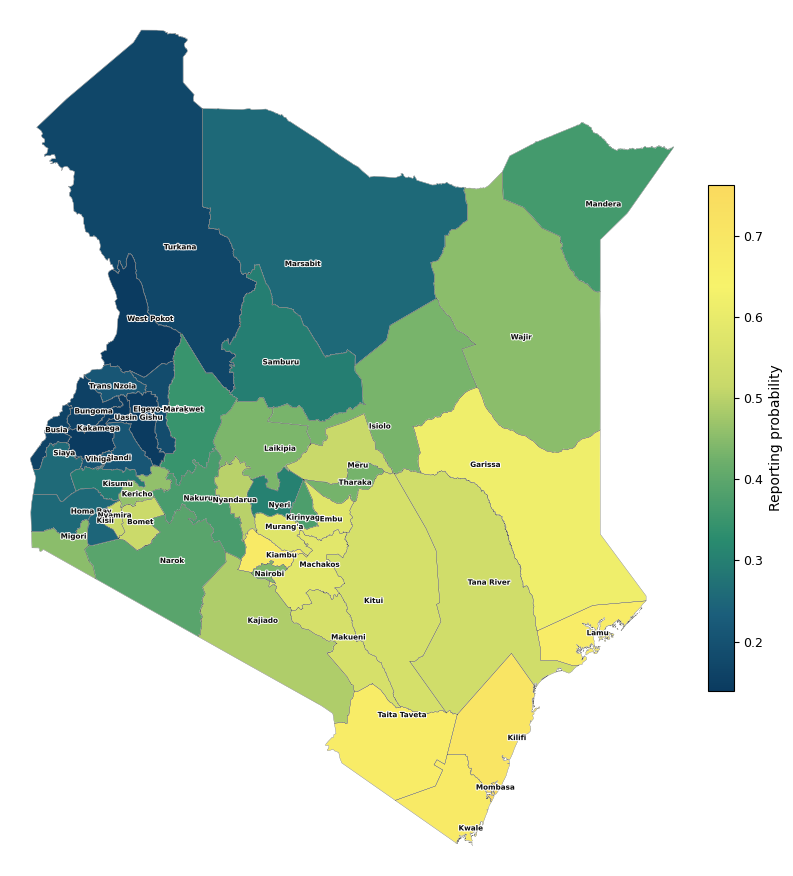

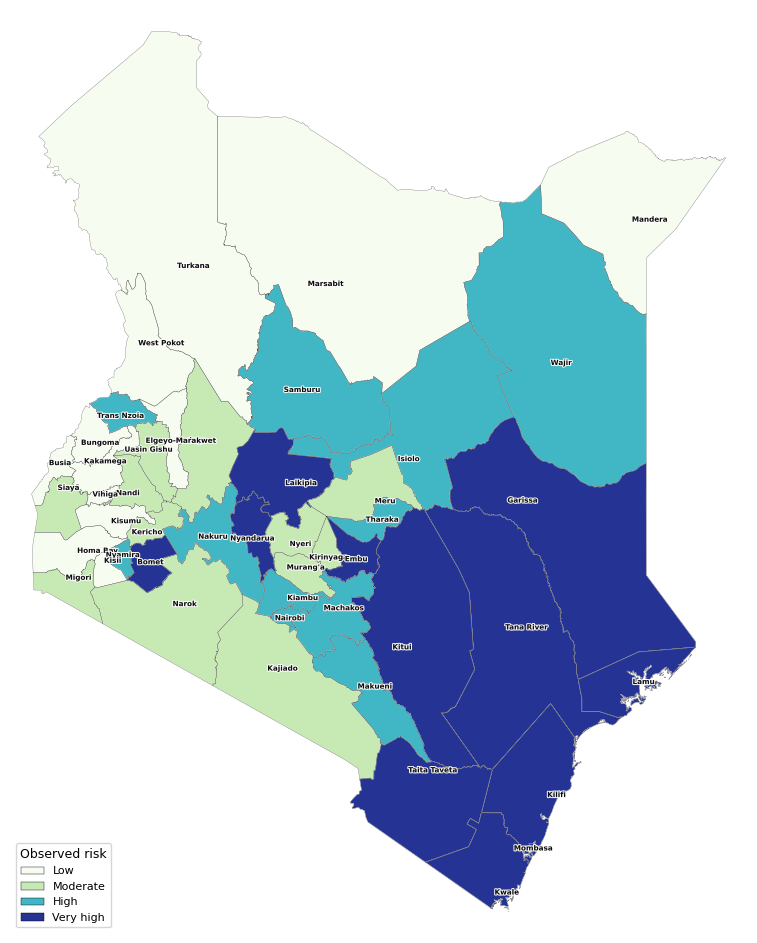

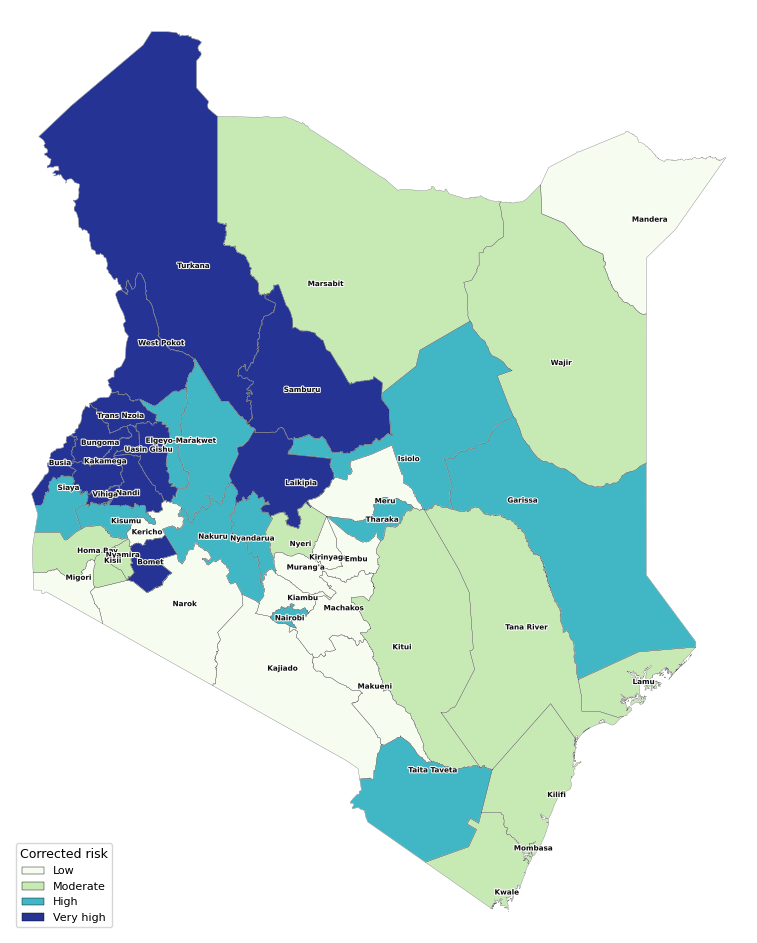

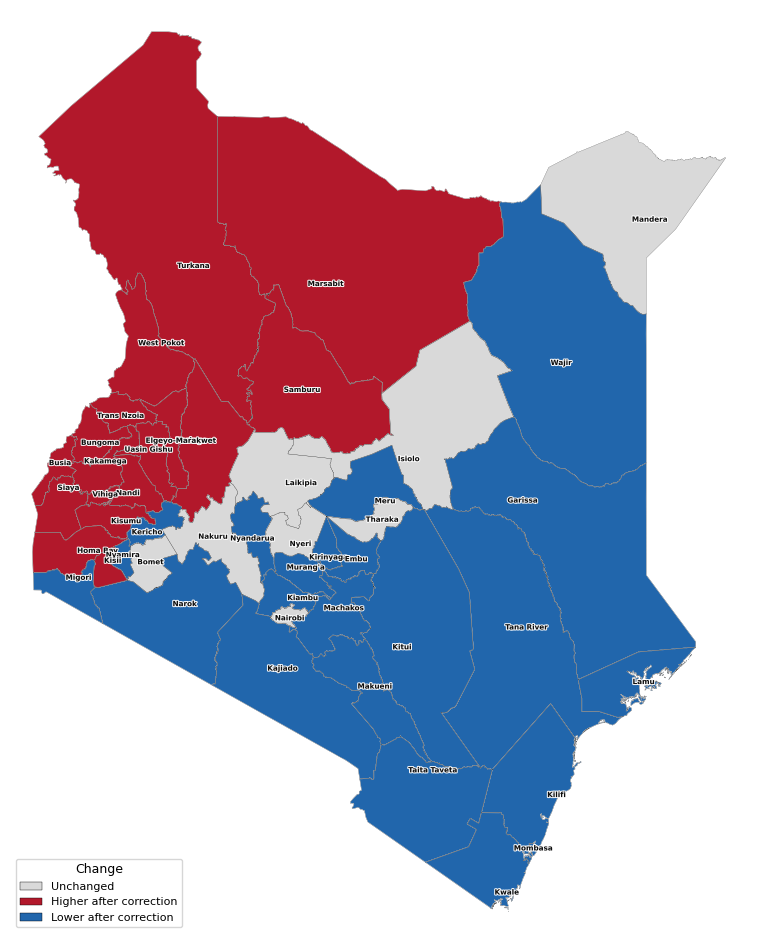

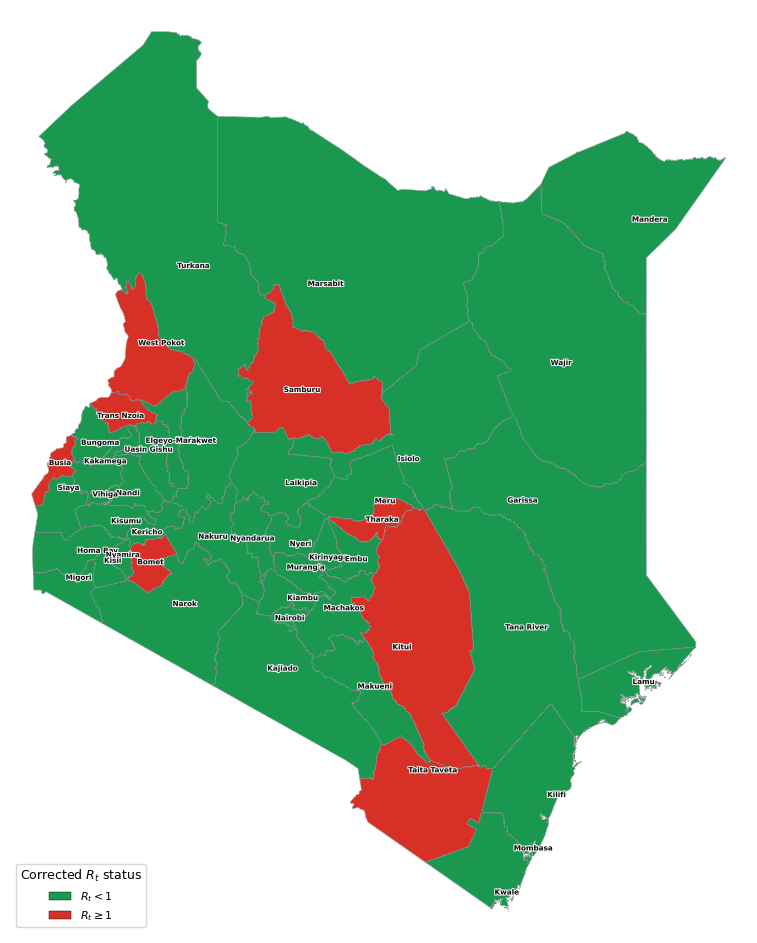

Finished generating county maps with no missing counties.
Files saved in
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps_no_missing

Number of Kenya counties in shapefile
47

Number of counties with mapped values
47

Minimum number of assigned synthetic units per county
1

Maximum number of assigned synthetic units per county
12
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps_no_missing\map1_reporting_probability_no_missing_with_county_names.png
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps_no_missing\map2_observed_risk_class_no_missing_with_county_names.png
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps_no_missing\map3_corrected_risk_class_no_missing_with_county_names.png
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps_no_missing\map4_risk_class_change_no_missing_with_county_names.png
C:\Users\Tosin\Desktop\Malaria\Kenya\kenya_final_county_maps_no_missing\map5_corrected_rt_status_no_missing_with_county_names.png

Risk

In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as path_effects
from matplotlib.colors import LinearSegmentedColormap

from pathlib import Path
from matplotlib.path import Path as MplPath
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection


np.random.seed(42)


BASE_DIR = Path(r"C:\Users\Tosin\Desktop\Malaria\Kenya")

GEOJSON_PATH = BASE_DIR / "geoBoundaries-KEN-ADM1.geojson"
ANALYTIC_DATA_PATH = BASE_DIR / "synthetic_kenya_malaria_analytic_dataset.csv"

OUTPUT_DIR = BASE_DIR / "kenya_final_county_maps_no_missing"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)


df = pd.read_csv(ANALYTIC_DATA_PATH, parse_dates=["date"])

latest_date = df["date"].max()
latest = df[df["date"] == latest_date].copy()


def estimate_rt(incidence, generation_interval):
    incidence = np.asarray(incidence, dtype=float)
    w = np.asarray(generation_interval, dtype=float)
    w = w / w.sum()

    rt = np.full(len(incidence), np.nan)

    for t in range(1, len(incidence)):
        max_lag = min(t, len(w))
        past = incidence[t - np.arange(1, max_lag + 1)]
        infectiousness = np.sum(past * w[:max_lag])

        if infectiousness > 0:
            rt[t] = incidence[t] / infectiousness

    return rt


generation_interval = np.array([0.25, 0.35, 0.25, 0.10, 0.05])

rt_rows = []

for sid, g in df.groupby("subcounty_id"):
    g = g.sort_values("date").copy()
    g["Rt_observed"] = estimate_rt(g["observed_cases"].values, generation_interval)
    g["Rt_corrected"] = estimate_rt(g["corrected_cases"].values, generation_interval)
    rt_rows.append(g[["subcounty_id", "date", "Rt_observed", "Rt_corrected"]])

rt_df = pd.concat(rt_rows, ignore_index=True)

latest = latest.merge(
    rt_df[rt_df["date"] == latest_date][["subcounty_id", "Rt_observed", "Rt_corrected"]],
    on="subcounty_id",
    how="left"
)


with open(GEOJSON_PATH, "r", encoding="utf-8") as f:
    geo = json.load(f)


def get_county_name(properties):
    possible_keys = ["shapeName", "ADM1_EN", "NAME_1", "name", "County", "county"]

    for key in possible_keys:
        if key in properties and properties[key] is not None:
            return str(properties[key])

    return str(properties)


def polygon_rings_from_geometry(geometry):
    rings = []

    if geometry["type"] == "Polygon":
        if len(geometry["coordinates"]) > 0:
            rings.append(np.asarray(geometry["coordinates"][0], dtype=float))

    elif geometry["type"] == "MultiPolygon":
        for polygon in geometry["coordinates"]:
            if len(polygon) > 0:
                rings.append(np.asarray(polygon[0], dtype=float))

    return rings


counties = []

for feature in geo["features"]:
    rings = polygon_rings_from_geometry(feature["geometry"])

    if rings:
        counties.append(
            {
                "name": get_county_name(feature["properties"]),
                "rings": rings
            }
        )


all_coords = np.vstack([ring for county in counties for ring in county["rings"]])

lon_min, lat_min = all_coords.min(axis=0)
lon_max, lat_max = all_coords.max(axis=0)


for county in counties:
    county["paths"] = [MplPath(ring[:, :2]) for ring in county["rings"]]


county_centroids = []

for county in counties:
    largest_ring = max(county["rings"], key=lambda ring: len(ring))
    centroid = largest_ring.mean(axis=0)

    county_centroids.append(
        {
            "county_name": county["name"],
            "centroid_lon": centroid[0],
            "centroid_lat": centroid[1]
        }
    )

county_centroids = pd.DataFrame(county_centroids)


spatial = latest[["subcounty_id", "x", "y"]].drop_duplicates().copy()

spatial["lon_raw"] = (
    lon_min
    + (spatial["x"] - spatial["x"].min())
    / (spatial["x"].max() - spatial["x"].min())
    * (lon_max - lon_min)
)

spatial["lat_raw"] = (
    lat_min
    + (spatial["y"] - spatial["y"].min())
    / (spatial["y"].max() - spatial["y"].min())
    * (lat_max - lat_min)
)


distance_rows = []

for county_i, county_row in county_centroids.iterrows():
    for unit_i, unit_row in spatial.iterrows():
        d = (
            (county_row["centroid_lon"] - unit_row["lon_raw"]) ** 2
            + (county_row["centroid_lat"] - unit_row["lat_raw"]) ** 2
        )

        distance_rows.append(
            {
                "county_i": county_i,
                "unit_i": unit_i,
                "county_name": county_row["county_name"],
                "subcounty_id": unit_row["subcounty_id"],
                "distance": d
            }
        )

distance_df = pd.DataFrame(distance_rows)
distance_df = distance_df.sort_values("distance").reset_index(drop=True)

assigned_units = set()
assigned_counties = set()
initial_assignments = []

for _, row in distance_df.iterrows():
    if row["county_name"] not in assigned_counties and row["subcounty_id"] not in assigned_units:
        initial_assignments.append(
            {
                "subcounty_id": row["subcounty_id"],
                "county_name": row["county_name"]
            }
        )

        assigned_counties.add(row["county_name"])
        assigned_units.add(row["subcounty_id"])

    if len(assigned_counties) == len(county_centroids):
        break


initial_assignment_df = pd.DataFrame(initial_assignments)

remaining_units = spatial[~spatial["subcounty_id"].isin(assigned_units)].copy()

remaining_assignments = []

for _, unit_row in remaining_units.iterrows():
    distance = (
        (county_centroids["centroid_lon"] - unit_row["lon_raw"]) ** 2
        + (county_centroids["centroid_lat"] - unit_row["lat_raw"]) ** 2
    )

    county_name = county_centroids.loc[distance.idxmin(), "county_name"]

    remaining_assignments.append(
        {
            "subcounty_id": unit_row["subcounty_id"],
            "county_name": county_name
        }
    )

remaining_assignment_df = pd.DataFrame(remaining_assignments)

spatial_assignment = pd.concat(
    [initial_assignment_df, remaining_assignment_df],
    ignore_index=True
)

latest2 = latest.drop(columns=["county_name"], errors="ignore").merge(
    spatial_assignment,
    on="subcounty_id",
    how="left"
)


missing_after_assignment = set(county_centroids["county_name"]) - set(latest2["county_name"])

if len(missing_after_assignment) > 0:
    raise ValueError(f"These counties still have no assigned units: {missing_after_assignment}")


def risk_class_from_quantiles(series):
    q1, q2, q3 = np.quantile(series, [0.25, 0.50, 0.75])

    return pd.cut(
        series,
        bins=[-np.inf, q1, q2, q3, np.inf],
        labels=["Low", "Moderate", "High", "Very high"],
        include_lowest=True
    )


county_values = latest2.groupby("county_name").agg(
    estimated_reporting_probability=("estimated_reporting_probability", "mean"),
    observed_incidence_per_1000=("observed_incidence_per_1000", "mean"),
    corrected_incidence_per_1000=("corrected_incidence_per_1000", "mean"),
    Rt_corrected=("Rt_corrected", "mean"),
    n_units=("subcounty_id", "count")
).reset_index()


county_values["difference_corrected_observed"] = (
    county_values["corrected_incidence_per_1000"]
    - county_values["observed_incidence_per_1000"]
)

county_values["observed_risk_class"] = risk_class_from_quantiles(
    county_values["observed_incidence_per_1000"]
).astype(str)

county_values["corrected_risk_class"] = risk_class_from_quantiles(
    county_values["corrected_incidence_per_1000"]
).astype(str)


risk_num = {
    "Low": 1,
    "Moderate": 2,
    "High": 3,
    "Very high": 4
}

county_values["observed_risk_num"] = county_values["observed_risk_class"].map(risk_num)
county_values["corrected_risk_num"] = county_values["corrected_risk_class"].map(risk_num)

county_values["risk_shift"] = (
    county_values["corrected_risk_num"]
    - county_values["observed_risk_num"]
)

county_values["misclassification"] = np.where(
    county_values["risk_shift"] > 0,
    "Higher after correction",
    np.where(
        county_values["risk_shift"] < 0,
        "Lower after correction",
        "Unchanged"
    )
)

county_values["corrected_elimination_status"] = np.where(
    county_values["Rt_corrected"] < 1,
    "Rt < 1",
    "Rt >= 1"
)


all_counties_check = pd.DataFrame({"county_name": county_centroids["county_name"]})

county_values = all_counties_check.merge(
    county_values,
    on="county_name",
    how="left"
)

if county_values.isna().any().any():
    raise ValueError("Some county map values are still missing. Check synthetic unit allocation.")


county_values.to_csv(OUTPUT_DIR / "county_level_map_values_no_missing.csv", index=False)
latest2.to_csv(OUTPUT_DIR / "latest_month_spatially_assigned_units_no_missing.csv", index=False)

value_lookup = {
    row["county_name"]: row
    for _, row in county_values.iterrows()
}


mpl.rcParams.update(
    {
        "font.size": 9,
        "axes.titlesize": 13,
        "axes.labelsize": 10,
        "savefig.dpi": 600,
        "font.family": "DejaVu Sans"
    }
)


# Create custom colormap: dark blue -> green -> yellow
# Based on your sample image
colors_bgy = ['#0B3B60', '#1B5E7B', '#2A8C6E', '#6BAE6B', '#C7D86A', '#F7F36B', '#FADA5E']
positions = [0.0, 0.15, 0.3, 0.45, 0.6, 0.8, 1.0]
blue_green_yellow_cmap = LinearSegmentedColormap.from_list('blue_green_yellow', 
                                                           list(zip(positions, colors_bgy)))

def add_boundaries(ax):
    for county in counties:
        for ring in county["rings"]:
            ax.plot(
                ring[:, 0],
                ring[:, 1],
                color="black",
                linewidth=0.20,
                alpha=0.70
            )


def format_map(ax):
    ax.set_xlim(lon_min - 0.25, lon_max + 0.25)
    ax.set_ylim(lat_min - 0.25, lat_max + 0.25)
    ax.set_aspect("equal")
    ax.axis("off")


def add_county_labels(ax):
    for _, row in county_centroids.iterrows():
        txt = ax.text(
            row["centroid_lon"],
            row["centroid_lat"],
            row["county_name"],
            fontsize=5.2,
            ha="center",
            va="center",
            color="black",
            alpha=0.95,
            weight='bold'
        )

        txt.set_path_effects(
            [
                path_effects.Stroke(linewidth=1.5, foreground="white"),
                path_effects.Normal()
            ]
        )


def make_patches_values(column):
    patches = []
    values = []

    for county in counties:
        val = value_lookup[county["name"]][column]

        for ring in county["rings"]:
            patches.append(MplPolygon(ring[:, :2], closed=True))
            values.append(val)

    return patches, np.asarray(values, dtype=float)


def plot_continuous(column, filename, label, cmap):
    patches, values = make_patches_values(column)

    fig, ax = plt.subplots(figsize=(8, 9.5))

    collection = PatchCollection(
        patches,
        cmap=cmap,
        linewidth=0.35,
        edgecolor="white"
    )

    collection.set_array(values)
    collection.set_clim(np.nanmin(values), np.nanmax(values))

    ax.add_collection(collection)

    add_boundaries(ax)
    add_county_labels(ax)
    format_map(ax)

    # No title
    # ax.set_title(title, pad=10)  # Removed

    cbar = fig.colorbar(collection, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label(label)

    plt.tight_layout()

    out = OUTPUT_DIR / filename
    plt.savefig(out, bbox_inches="tight", dpi=600)
    plt.show()

    return out


def plot_categorical(column, filename, color_map, legend_title):
    fig, ax = plt.subplots(figsize=(8, 9.5))

    for county in counties:
        val = value_lookup[county["name"]][column]
        facecolor = color_map[val]

        for ring in county["rings"]:
            patch = MplPolygon(
                ring[:, :2],
                closed=True,
                facecolor=facecolor,
                edgecolor="white",
                linewidth=0.35
            )

            ax.add_patch(patch)

    add_boundaries(ax)
    add_county_labels(ax)
    format_map(ax)

    # No title
    # ax.set_title(title, pad=10)  # Removed

    handles = [
        mpl.patches.Patch(
            facecolor=value,
            edgecolor="black",
            linewidth=0.3,
            label=key
        )
        for key, value in color_map.items()
    ]

    ax.legend(
        handles=handles,
        title=legend_title,
        loc="lower left",
        frameon=True,
        fontsize=8,
        title_fontsize=9
    )

    plt.tight_layout()

    out = OUTPUT_DIR / filename
    plt.savefig(out, bbox_inches="tight", dpi=600)
    plt.show()

    return out


risk_colors = {
    "Low": "#F7FCF0",
    "Moderate": "#C7E9B4",
    "High": "#41B6C4",
    "Very high": "#253494"
}

misclassification_colors = {
    "Unchanged": "#D9D9D9",
    "Higher after correction": "#B2182B",
    "Lower after correction": "#2166AC"
}

rt_colors = {
    "Rt < 1": "#1A9850",
    "Rt >= 1": "#D73027"
}


map_files = []

# Map 1: Reporting probability with blue-green-yellow colormap (matching your sample)
map_files.append(
    plot_continuous(
        column="estimated_reporting_probability",
        filename="map1_reporting_probability_no_missing_with_county_names.png",
        label="Reporting probability",
        cmap=blue_green_yellow_cmap  # Using custom blue-green-yellow colormap
    )
)

# Map 2: Observed risk class (no title)
map_files.append(
    plot_categorical(
        column="observed_risk_class",
        filename="map2_observed_risk_class_no_missing_with_county_names.png",
        color_map=risk_colors,
        legend_title="Observed risk"
    )
)

# Map 3: Corrected risk class (no title)
map_files.append(
    plot_categorical(
        column="corrected_risk_class",
        filename="map3_corrected_risk_class_no_missing_with_county_names.png",
        color_map=risk_colors,
        legend_title="Corrected risk"
    )
)

# Map 4: Risk class change (no title)
map_files.append(
    plot_categorical(
        column="misclassification",
        filename="map4_risk_class_change_no_missing_with_county_names.png",
        color_map=misclassification_colors,
        legend_title="Change"
    )
)

# Map 5: Elimination readiness (no title, with math mode)
fig, ax = plt.subplots(figsize=(8, 9.5))

for county in counties:
    val = value_lookup[county["name"]]["corrected_elimination_status"]
    facecolor = rt_colors[val]

    for ring in county["rings"]:
        patch = MplPolygon(
            ring[:, :2],
            closed=True,
            facecolor=facecolor,
            edgecolor="white",
            linewidth=0.35
        )
        ax.add_patch(patch)

add_boundaries(ax)
add_county_labels(ax)
format_map(ax)

# No title
# ax.set_title("Elimination readiness based on corrected Rt", pad=10)  # Removed

# Create legend with math mode
handles = [
    mpl.patches.Patch(
        facecolor=rt_colors["Rt < 1"],
        edgecolor="black",
        linewidth=0.3,
        label=r"$R_t < 1$"
    ),
    mpl.patches.Patch(
        facecolor=rt_colors["Rt >= 1"],
        edgecolor="black", 
        linewidth=0.3,
        label=r"$R_t \geq 1$"
    )
]

ax.legend(
    handles=handles,
    title=r"Corrected $R_t$ status",
    loc="lower left",
    frameon=True,
    fontsize=8,
    title_fontsize=9
)

plt.tight_layout()

out = OUTPUT_DIR / "map5_corrected_rt_status_no_missing_with_county_names.png"
plt.savefig(out, bbox_inches="tight", dpi=600)
plt.show()

map_files.append(out)


print("Finished generating county maps with no missing counties.")
print("Files saved in")
print(OUTPUT_DIR)

print("\nNumber of Kenya counties in shapefile")
print(len(county_centroids))

print("\nNumber of counties with mapped values")
print(county_values["county_name"].nunique())

print("\nMinimum number of assigned synthetic units per county")
print(county_values["n_units"].min())

print("\nMaximum number of assigned synthetic units per county")
print(county_values["n_units"].max())

for file in map_files:
    print(file)

print("\nRisk class change summary")
print(county_values["misclassification"].value_counts())

print("\nCorrected Rt status summary")
print(county_values["corrected_elimination_status"].value_counts())